# Laboratorio 7 — NLP end-to-end y embeddings (Kaggle)

Notebook autocontenido para **Kaggle con GPU**. Implementa WikiText-103, SGNS propio en PyTorch, Word2Vec de gensim, GloVe y clasificación de AG News. No depende de archivos `src/`.

Antes de ejecutar: en **Settings → Accelerator** elija GPU y active Internet. Use **Run All**. Los checkpoints se escriben en `/kaggle/working/lab7`; si una sesión termina, guarde esa carpeta como output y restaure sus checkpoints en la siguiente versión. `FAST_MODE=True` sirve sólo para verificar el pipeline; los resultados de entrega requieren `FAST_MODE=False`.

In [1]:
%pip install -q "datasets>=2.19,<5" "gensim>=4.3,<5" "scipy>=1.12,<2" "scikit-learn>=1.4,<2" seaborn nltk psutil


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
from collections import Counter, defaultdict
import os, re, gc, json, math, time, random, platform, unicodedata
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import spearmanr
from datasets import load_dataset
import gensim, gensim.downloader as api
from gensim.models import Word2Vec, KeyedVectors
from gensim.test.utils import datapath
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.manifold import TSNE
from nltk.tokenize import TreebankWordTokenizer

SEED=42; FAST_MODE=False; RUN_EXPERIMENTS=True; RUN_CLASSIFIERS=True; RUN_FRACTION_CURVES=True
MAX_TOKENS=20_000_000 if not FAST_MODE else 300_000
EPOCHS=3 if not FAST_MODE else 1
BATCH_SIZE=8192; WINDOW=5; NEGATIVES=5; MIN_COUNT=5; MAX_VOCAB=30_000; SUBSAMPLE_T=1e-5
ROOT=Path('/kaggle/working/lab7') if Path('/kaggle/working').exists() else Path.cwd()/'kaggle_output'
for p in ['checkpoints','embeddings','tables','figures','results']: (ROOT/p).mkdir(parents=True,exist_ok=True)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED); torch.backends.cuda.matmul.allow_tf32=True
print({'root':str(ROOT),'device':str(DEVICE),'gpu':torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
       'python':platform.python_version(),'torch':torch.__version__,'gensim':gensim.__version__})
assert torch.cuda.is_available() or FAST_MODE, 'Active una GPU de Kaggle o use FAST_MODE sólo para depuración.'

{'root': '/kaggle/working/lab7', 'device': 'cuda', 'gpu': 'Tesla T4', 'python': '3.13.15', 'torch': '2.11.0+cu128', 'gensim': '4.4.0'}


## 1. Investigación breve

- `nn.Embedding(num_embeddings, embedding_dim, padding_idx, sparse)` es una tabla indexable de vectores. `padding_idx` deja fija la fila de relleno y `sparse=True` produce gradientes dispersos, útiles con vocabularios grandes. `nn.Embedding.from_pretrained(weight, freeze)` inicializa desde una matriz existente y permite congelarla.
- `nn.EmbeddingBag` combina búsquedas y reducción sin materializar secuencias rellenadas. Recibe IDs concatenados y `offsets`; `mean`, `sum` y `max` calculan, respectivamente, promedio, suma o máximo por documento.
- CBOW predice la palabra central desde su contexto; skip-gram predice palabras de contexto desde la central y suele representar mejor palabras poco frecuentes. SGNS usa dos matrices: $W$ (palabra de entrada) y $W'$ (palabra de salida/contexto). Se optimizan roles distintos; convencionalmente se conserva $W$, aunque combinarlas también puede evaluarse.
- Word2Vec es predictivo: aprende resolviendo una tarea local. GloVe factoriza implícitamente estadísticas globales de coocurrencia ponderadas.

Normalización elegida: Unicode NFKC, minúsculas, apóstrofes tipográficos unificados, palabras/contracciones/guiones conservados, números y puntuación como tokens. No se eliminan stopwords. Minúsculas y tratamiento de puntuación/números se aplican igual al corpus y AG News; GloVe 6B es principalmente minúsculo y contiene puntuación/números, por lo que estas decisiones reducen OOV sin alterar sus vectores.

In [3]:
TOKEN_RE=re.compile(r"[a-z]+(?:['-][a-z]+)*|\d+(?:[.,]\d+)*|[^\w\s]",re.I)
def normalize_text(s):
    return unicodedata.normalize('NFKC',s).lower().replace('’',"'").replace('`',"'")
def tokenize(s): return TOKEN_RE.findall(normalize_text(s))
examples=["I can't re-use 3.14-year-old data.","Dr. Smith's model—well, it works!","They've paid $10.50.",
          "state-of-the-art NLP","U.S.A. vs. UK","rock 'n' roll","Version 2.0-beta",
          "Cats, dogs... and birds?","The 1990s weren't easy.","e-mail addresses@example.com"]
tb=TreebankWordTokenizer()
tok_cmp=pd.DataFrame({'text':examples,'propio':[tokenize(x) for x in examples],
                      'Treebank':[tb.tokenize(normalize_text(x)) for x in examples]})
tok_cmp.to_csv(ROOT/'tables/tokenizer_comparison.csv',index=False); tok_cmp

,text,propio,Treebank
0,I can't re-use 3.14-year-old data.,"[i, can't, re-use, 3.14, -, year-old, data, .]","[i, ca, n't, re-use, 3.14-year-old, data, .]"
1,"Dr. Smith's model—well, it works!","[dr, ., smith's, model, —, well, ,, it, works, !]","[dr., smith, 's, model—well, ,, it, works, !]"
2,They've paid $10.50.,"[they've, paid, $, 10.50, .]","[they, 've, paid, $, 10.50, .]"
3,state-of-the-art NLP,"[state-of-the-art, nlp]","[state-of-the-art, nlp]"
4,U.S.A. vs. UK,"[u, ., s, ., a, ., vs, ., uk]","[u.s.a., vs., uk]"
5,rock 'n' roll,"[rock, ', n, ', roll]","[rock, 'n, ', roll]"
6,Version 2.0-beta,"[version, 2.0, -, beta]","[version, 2.0-beta]"
7,"Cats, dogs... and birds?","[cats, ,, dogs, ., ., ., and, birds, ?]","[cats, ,, dogs, ..., and, birds, ?]"
8,The 1990s weren't easy.,"[the, 1990, s, weren't, easy, .]","[the, 1990s, were, n't, easy, .]"
9,e-mail addresses@example.com,"[e-mail, addresses, @, example, ., com]","[e-mail, addresses, @, example.com]"


El tokenizador propio mantiene contracciones y compuestos con guion; Treebank separa varias contracciones y signos. Las abreviaturas con puntos y los correos también evidencian diferencias. Esta comparación es diagnóstica: todo el pipeline usa exclusivamente `tokenize`.

In [4]:
corpus=load_dataset('Salesforce/wikitext','wikitext-103-raw-v1')
news=load_dataset('fancyzhx/ag_news')
glove=api.load('glove-wiki-gigaword-100')
print(corpus,news,'GloVe vocab:',len(glove))

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-103-raw-v1/test-00000-of-00001.(…): downloading bytes:           |  0.00B            

wikitext-103-raw-v1/train-00000-of-00002(…): reconstructing file:   0%|          |  0.00B /  157MB            

wikitext-103-raw-v1/train-00000-of-00002(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

[==================================================] 100.0% 128.1/128.1MB downloaded
DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
}) DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
}) GloVe vocab: 400000


Tokenizando WikiText-103:   0%|          | 0/1801350 [00:00<?, ?it/s]

,articulos_titulos,lineas,lineas_no_vacias,tokens,tipos,tokens_subconjunto
0,305074,1801350,1165029,105477646,483937,20000000


,top_k,cobertura_pct
0,10,29.244950
1,1000,70.692095
2,30000,96.811785


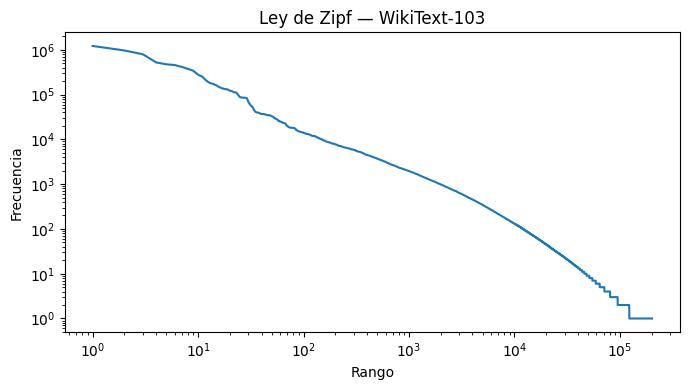

In [5]:
# Una pasada cuenta todo WikiText; sólo retiene el prefijo de entrenamiento para limitar RAM.
full_count=Counter(); subset_tokens=[]; n_lines=n_nonempty=n_articles=0
title_re=re.compile(r'^\s*=+[^=].*[^=]=+\s*$')
for row in tqdm(corpus['train'],desc='Tokenizando WikiText-103'):
    text=row['text']; n_lines+=1; n_nonempty+=bool(text.strip()); n_articles+=bool(title_re.match(text))
    ts=tokenize(text); full_count.update(ts)
    if len(subset_tokens)<MAX_TOKENS: subset_tokens.extend(ts[:MAX_TOKENS-len(subset_tokens)])
stats=pd.DataFrame([{'articulos_titulos':n_articles,'lineas':n_lines,'lineas_no_vacias':n_nonempty,
                     'tokens':sum(full_count.values()),'tipos':len(full_count),'tokens_subconjunto':len(subset_tokens)}])
stats.to_csv(ROOT/'tables/corpus_stats.csv',index=False); display(stats)
sub_count=Counter(subset_tokens); ranked=sub_count.most_common()
cov=[]
for k in [10,1000,30000]: cov.append({'top_k':k,'cobertura_pct':100*sum(v for _,v in ranked[:k])/len(subset_tokens)})
display(pd.DataFrame(cov)); pd.DataFrame(cov).to_csv(ROOT/'tables/top_k_coverage.csv',index=False)
freq=np.array([v for _,v in ranked]); plt.figure(figsize=(7,4)); plt.loglog(np.arange(1,len(freq)+1),freq)
plt.xlabel('Rango'); plt.ylabel('Frecuencia'); plt.title('Ley de Zipf — WikiText-103'); plt.tight_layout(); plt.savefig(ROOT/'figures/zipf.png'); plt.show()

In [6]:
mc=[]
for m in [2,5,10]:
    kept=sum(c>=m for c in sub_count.values()); unk=sum(c for c in sub_count.values() if c<m)
    mc.append({'min_count':m,'vocabulario':kept,'tokens_unk_pct':100*unk/len(subset_tokens)})
display(pd.DataFrame(mc)); pd.DataFrame(mc).to_csv(ROOT/'tables/min_count.csv',index=False)
vocab_words=[w for w,c in ranked if c>=MIN_COUNT][:MAX_VOCAB-1]
itos=['<unk>']+vocab_words; stoi={w:i for i,w in enumerate(itos)}
ids=np.fromiter((stoi.get(w,0) for w in subset_tokens),dtype=np.int32,count=len(subset_tokens))
counts=np.bincount(ids,minlength=len(itos)).astype(np.int64); del subset_tokens; gc.collect()
freqs=counts/counts.sum(); keep_prob=np.ones(len(itos),dtype=np.float64)
nz=freqs>0; keep_prob[nz]=np.minimum(1.0,(np.sqrt(freqs[nz]/SUBSAMPLE_T)+1)*(SUBSAMPLE_T/freqs[nz])); keep_prob[0]=0
rng=np.random.default_rng(SEED); kept_ids=ids[rng.random(len(ids))<keep_prob[ids]]
kept_counts=np.bincount(kept_ids,minlength=len(itos))
sub_report=pd.DataFrame([{'palabra':w,'apariciones':int(counts[stoi.get(w,0)]),
                          'descarte_esperado_pct':100*(1-keep_prob[stoi.get(w,0)]),
                          'descarte_observado_pct':100*(1-kept_counts[stoi.get(w,0)]/max(1,counts[stoi.get(w,0)]))} for w in ['the','of','and']])
def pair_count(n,w): return max(0,2*w*n-w*(w+1))
pair_table=pd.DataFrame([{'subsampling':False,'tokens':len(ids),'pares_epoch':pair_count(len(ids),WINDOW)},
                         {'subsampling':True,'tokens':len(kept_ids),'pares_epoch':pair_count(len(kept_ids),WINDOW)}])
display(sub_report,pair_table); sub_report.to_csv(ROOT/'tables/subsampling.csv',index=False); pair_table.to_csv(ROOT/'tables/pairs.csv',index=False)
print('El submuestreo evita que palabras muy frecuentes dominen el gradiente y reduce costo sin perder mucha señal semántica.')

,min_count,vocabulario,tokens_unk_pct
0,2,122650,0.395915
1,5,71230,1.076975
2,10,48319,1.829805


,palabra,apariciones,descarte_esperado_pct,descarte_observado_pct
0,the,1219440,98.702936,98.712278
1,of,523468,98.007139,98.010576
2,and,474862,97.905628,97.916447


,subsampling,tokens,pares_epoch
0,False,20000000,199999970
1,True,5729385,57293820


El submuestreo evita que palabras muy frecuentes dominen el gradiente y reduce costo sin perder mucha señal semántica.


## 2. SGNS propio y evaluación de selección

Los negativos se muestrean con $p(w)\propto f(w)^{0.75}$. Los pares se generan por lotes, sin materializarlos en RAM. Cada época guarda pesos, optimizador, métricas, tiempo y memoria pico; volver a ejecutar reanuda el checkpoint. WordSim-353 y `questions-words` son los únicos criterios de selección. SimLex queda reservado para la evaluación final.

In [7]:
def read_pairs(path):
    rows=[]
    with open(path,encoding='utf8') as f:
        for line in f:
            p=line.strip().lower().split()
            # WordSim: score en columna 3; SimLex: POS en 3 y score en 4.
            # Se omiten encabezados, comentarios y filas incompletas.
            score_i=3 if 'simlex' in str(path).lower() else 2
            if len(p)>score_i and not p[0].startswith('#'):
                try: rows.append((p[0],p[1],float(p[score_i])))
                except (ValueError, IndexError): pass
    return rows
def read_analogies(path):
    out=[]; cat=''
    with open(path,encoding='utf8') as f:
        for line in f:
            if line.startswith(':'): cat=line[1:].strip(); continue
            p=line.lower().split()
            if len(p)==4: out.append((cat,*p))
    return out
WORDSIM=read_pairs(datapath('wordsim353.tsv')); SIMLEX=read_pairs(datapath('simlex999.txt')); QUESTIONS=read_analogies(datapath('questions-words.txt'))
def normalized(x): return x/(np.linalg.norm(x,axis=1,keepdims=True)+1e-12)
def wordsim_score(words,vectors,rows=WORDSIM):
    ix={w:i for i,w in enumerate(words)}; gold=[]; pred=[]; v=normalized(vectors.astype(np.float32))
    for a,b,s in rows:
        if a in ix and b in ix: gold.append(s); pred.append(float(v[ix[a]]@v[ix[b]]))
    return {'spearman':float(spearmanr(gold,pred).statistic) if len(gold)>2 else np.nan,'coverage':len(gold),'total':len(rows)}
@torch.inference_mode()
def analogy_benchmark(words,vectors,method='add',questions=QUESTIONS,batch=128):
    ix={w:i for i,w in enumerate(words)}; q=[x for x in questions if all(w in ix for w in x[1:])]
    mat=torch.as_tensor(normalized(vectors.astype(np.float32)),device=DEVICE); records=[]
    for j in range(0,len(q),batch):
        z=q[j:j+batch]; ai=torch.tensor([ix[x[1]] for x in z],device=DEVICE); bi=torch.tensor([ix[x[2]] for x in z],device=DEVICE)
        ci=torch.tensor([ix[x[3]] for x in z],device=DEVICE); target=np.array([ix[x[4]] for x in z])
        if method=='add': score=(mat[bi]-mat[ai]+mat[ci])@mat.T
        else:
            score=((mat[bi]@mat.T+1)/2)*((mat[ci]@mat.T+1)/2)/(((mat[ai]@mat.T+1)/2)+1e-4)
        score.scatter_(1,ai[:,None],-1e9); score.scatter_(1,bi[:,None],-1e9); score.scatter_(1,ci[:,None],-1e9)
        pred=score.argmax(1).cpu().numpy()
        records.extend({'categoria':x[0],'correcta':int(p==t)} for x,p,t in zip(z,pred,target))
    d=pd.DataFrame(records); total=len(questions)
    if d.empty: return pd.DataFrame(),{'coverage':0,'total':total,'accuracy':np.nan,'semantic':np.nan,'syntactic':np.nan}
    syn=d.categoria.str.startswith('gram'); summary={'coverage':len(d),'total':total,'accuracy':d.correcta.mean(),
        'semantic':d.loc[~syn,'correcta'].mean(),'syntactic':d.loc[syn,'correcta'].mean()}
    return d.groupby('categoria').correcta.agg(['sum','count','mean']).reset_index(),summary
def nearest(words,vectors,queries,k=5):
    ix={w:i for i,w in enumerate(words)}; v=normalized(vectors.astype(np.float32)); out={}
    for w in queries:
        if w in ix:
            s=v@v[ix[w]]; s[ix[w]]=-9; top=np.argpartition(s,-k)[-k:]; top=top[np.argsort(s[top])[::-1]]
            out[w]=[(words[i],float(s[i])) for i in top]
    return out

In [8]:
class SGNS(nn.Module):
    def __init__(self,n,d):
        super().__init__(); self.input=nn.Embedding(n,d,sparse=True); self.output=nn.Embedding(n,d,sparse=True)
        nn.init.uniform_(self.input.weight,-.5/d,.5/d); nn.init.zeros_(self.output.weight)
    def forward(self,c,o,neg):
        vc=self.input(c); vo=self.output(o); vn=self.output(neg)
        return -(F.logsigmoid((vc*vo).sum(1))+F.logsigmoid(-torch.bmm(vn,vc.unsqueeze(2)).squeeze(2)).sum(1)).mean()
def pair_batches(x,keep,w,batch,seed):
    r=np.random.default_rng(seed); y=x[r.random(len(x))<keep[x]]; order=r.permutation(np.arange(1,w+1))
    for off in order:
        a=y[:-off]; b=y[off:]
        for left,right in [(a,b),(b,a)]:
            for j in range(0,len(left),batch): yield left[j:j+batch],right[j:j+batch]
def train_sgns(cfg):
    path=ROOT/'checkpoints'/f"{cfg['id']}.pt"; n=cfg['tokens']; model=SGNS(len(itos),cfg['dim']).to(DEVICE)
    opt=torch.optim.SparseAdam(model.parameters(),lr=cfg['lr']); history=[]; start=0
    if path.exists():
        ck=torch.load(path,map_location=DEVICE,weights_only=False); model.load_state_dict(ck['model']); opt.load_state_dict(ck['optimizer']); history=ck['history']; start=len(history)
    dist=torch.tensor(counts**.75,dtype=torch.float32,device=DEVICE); dist[0]=0; dist/=dist.sum()
    for ep in range(start,cfg['epochs']):
        model.train(); losses=[]; t0=time.time();
        if DEVICE.type=='cuda': torch.cuda.reset_peak_memory_stats()
        for c,o in tqdm(pair_batches(ids[:n],keep_prob, cfg['window'],BATCH_SIZE,SEED+ep),desc=f"{cfg['id']} e{ep+1}"):
            c=torch.as_tensor(c,dtype=torch.long,device=DEVICE); o=torch.as_tensor(o,dtype=torch.long,device=DEVICE)
            neg=torch.multinomial(dist,len(c)*cfg['negative'],replacement=True).view(len(c),cfg['negative'])
            opt.zero_grad(set_to_none=True); loss=model(c,o,neg); loss.backward(); opt.step(); losses.append(float(loss))
        vec=model.input.weight.detach().cpu().numpy(); _,ana=analogy_benchmark(itos,vec,'add'); ws=wordsim_score(itos,vec)
        row={'experiment_id':cfg['id'],'epoch':ep+1,'loss':np.mean(losses),'seconds':time.time()-t0,
             'gpu_peak_mb':torch.cuda.max_memory_allocated()/2**20 if DEVICE.type=='cuda' else 0,
             'analogy_total':ana['accuracy'],'analogy_semantic':ana['semantic'],'analogy_syntactic':ana['syntactic'],
             'wordsim_spearman':ws['spearman'],'neighbors':json.dumps(nearest(itos,vec,['king','france','computer','good','january','run']))}
        history.append(row); torch.save({'model':model.state_dict(),'optimizer':opt.state_dict(),'history':history,'config':cfg},path)
        pd.DataFrame(history).to_csv(ROOT/'results'/f"{cfg['id']}_history.csv",index=False); print(row)
    return model,history
experiments=[
 {'id':'E20M_d50','tokens':MAX_TOKENS,'dim':50}, {'id':'E20M_d100','tokens':MAX_TOKENS,'dim':100},
 {'id':'E20M_d300','tokens':MAX_TOKENS,'dim':300}, {'id':'E25pct_d100','tokens':max(1,MAX_TOKENS//4),'dim':100},
 {'id':'E50pct_d100','tokens':max(1,MAX_TOKENS//2),'dim':100}]
for x in experiments: x.update(window=WINDOW,negative=NEGATIVES,lr=.003,epochs=EPOCHS,min_count=MIN_COUNT,subsample=SUBSAMPLE_T)
pd.DataFrame(experiments).to_csv(ROOT/'tables/experiment_configurations.csv',index=False); pd.DataFrame(experiments)

,id,tokens,dim,window,negative,lr,epochs,min_count,subsample
0,E20M_d50,20000000,50,5,5,0.003,3,5,0.00001
1,E20M_d100,20000000,100,5,5,0.003,3,5,0.00001
2,E20M_d300,20000000,300,5,5,0.003,3,5,0.00001
3,E25pct_d100,5000000,100,5,5,0.003,3,5,0.00001
4,E50pct_d100,10000000,100,5,5,0.003,3,5,0.00001


E20M_d50 e1: 0it [00:00, ?it/s]

/tmp/ipykernel_23/3203169468.py:26: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  opt.zero_grad(set_to_none=True); loss=model(c,o,neg); loss.backward(); opt.step(); losses.append(float(loss))


{'experiment_id': 'E20M_d50', 'epoch': 1, 'loss': np.float64(2.5031944177491323), 'seconds': 22.897632122039795, 'gpu_peak_mb': 91.15869140625, 'analogy_total': np.float64(0.07764685937102653), 'analogy_semantic': np.float64(0.05902004454342984), 'analogy_syntactic': np.float64(0.08580134064594759), 'wordsim_spearman': 0.5550239747909566, 'neighbors': '{"king": [["throne", 0.908845067024231], ["duke", 0.8586443066596985], ["pope", 0.8496062755584717], ["1275", 0.8415801525115967], ["heir", 0.8350422978401184]], "france": [["italy", 0.9125218987464905], ["spain", 0.9041780233383179], ["austria", 0.8442546129226685], ["netherlands", 0.8390598893165588], ["hungary", 0.8185223937034607]], "computer": [["interface", 0.914470911026001], ["hardware", 0.8994764089584351], ["computers", 0.894682765007019], ["controller", 0.8902751207351685], ["simulation", 0.8890461325645447]], "good": [["aren", 0.847861111164093], ["didn", 0.8310566544532776], ["happier", 0.8302826285362244], ["pretty", 0.8276

E20M_d50 e2: 0it [00:00, ?it/s]

{'experiment_id': 'E20M_d50', 'epoch': 2, 'loss': np.float64(2.3021230862651554), 'seconds': 22.00617790222168, 'gpu_peak_mb': 91.4619140625, 'analogy_total': np.float64(0.17165381029075188), 'analogy_semantic': np.float64(0.12444320712694877), 'analogy_syntactic': np.float64(0.1923217550274223), 'wordsim_spearman': 0.6052382588556213, 'neighbors': '{"king": [["conqueror", 0.8152318596839905], ["earls", 0.8094860315322876], ["1189", 0.8078225255012512], ["anjou", 0.8069732189178467], ["earldom", 0.8027049899101257]], "france": [["spain", 0.8714485168457031], ["italy", 0.8583108186721802], ["portugal", 0.8312157392501831], ["netherlands", 0.8040916919708252], ["sweden", 0.780892014503479]], "computer": [["computers", 0.8909885883331299], ["simulation", 0.8579235672950745], ["spacewar", 0.8571408987045288], ["software", 0.8519064784049988], ["adobe", 0.8388596773147583]], "good": [["aren", 0.8544808626174927], ["plenty", 0.8222371339797974], ["obviously", 0.818673849105835], ["wouldn", 0

...

{'experiment_id': 'E50pct_d100', 'epoch': 1, 'loss': np.float64(2.5461787488801138), 'seconds': 14.187493801116943, 'gpu_peak_mb': 146.00830078125, 'analogy_total': np.float64(0.039247266254132405), 'analogy_semantic': np.float64(0.03758351893095768), 'analogy_syntactic': np.float64(0.039975624619134675), 'wordsim_spearman': 0.4915648794470375, 'neighbors': '{"king": [["throne", 0.9569497108459473], ["emperor", 0.8905652165412903], ["mar", 0.8694545030593872], ["heir", 0.8682193756103516], ["reign", 0.8678277730941772]], "france": [["italy", 0.9186693429946899], ["dutch", 0.895523190498352], ["spain", 0.8931760787963867], ["austria", 0.88334059715271], ["greece", 0.8735063076019287]], "computer": [["hardware", 0.955944836139679], ["interface", 0.9208502769470215], ["software", 0.911520779132843], ["computers", 0.9090406894683838], ["user", 0.9064668416976929]], "good": [["hard", 0.8684953451156616], ["something", 0.8488051891326904], ["feel", 0.8455333709716797], ["nice", 0.84348922967

E50pct_d100 e2: 0it [00:00, ?it/s]

{'experiment_id': 'E50pct_d100', 'epoch': 2, 'loss': np.float64(2.2997181916577474), 'seconds': 14.14867901802063, 'gpu_peak_mb': 146.052734375, 'analogy_total': np.float64(0.11579215054674917), 'analogy_semantic': np.float64(0.08379732739420935), 'analogy_syntactic': np.float64(0.12979890310786105), 'wordsim_spearman': 0.5930624660952859, 'neighbors': '{"king": [["throne", 0.8347089290618896], ["bishop", 0.8129761219024658], ["nephew", 0.7958358526229858], ["1216", 0.794091522693634], ["henry", 0.7913731932640076]], "france": [["spain", 0.8678401708602905], ["italy", 0.8123328685760498], ["portugal", 0.7973577380180359], ["czechoslovakia", 0.7665709257125854], ["luxembourg", 0.7621276378631592]], "computer": [["blackley", 0.8338171243667603], ["computers", 0.8233559131622314], ["simulation", 0.8219506740570068], ["simulator", 0.8179140686988831], ["pixel", 0.8111872673034668]], "good": [["enough", 0.7717931270599365], ["pretty", 0.760166585445404], ["quite", 0.7588335871696472], ["uni

E50pct_d100 e3: 0it [00:00, ?it/s]

{'experiment_id': 'E50pct_d100', 'epoch': 3, 'loss': np.float64(2.230784493616649), 'seconds': 14.164592504501343, 'gpu_peak_mb': 146.173828125, 'analogy_total': np.float64(0.1457150122912605), 'analogy_semantic': np.float64(0.09409799554565701), 'analogy_syntactic': np.float64(0.16831200487507617), 'wordsim_spearman': 0.6225554406658298, 'neighbors': '{"king": [["throne", 0.8077141046524048], ["1135", 0.7966592907905579], ["1199", 0.7748903632164001], ["fulk", 0.7655090689659119], ["angevin", 0.7637972831726074]], "france": [["spain", 0.7773396968841553], ["italy", 0.7090095281600952], ["portugal", 0.6621417999267578], ["belgium", 0.6618318557739258], ["netherlands", 0.6516176462173462]], "computer": [["computers", 0.8427630662918091], ["mainframe", 0.7770035266876221], ["software", 0.7700690031051636], ["atari", 0.7690114974975586], ["blackley", 0.7657586336135864]], "good": [["come", 0.6867161393165588], ["ll", 0.6753442883491516], ["sure", 0.6547558307647705], ["things", 0.65392708

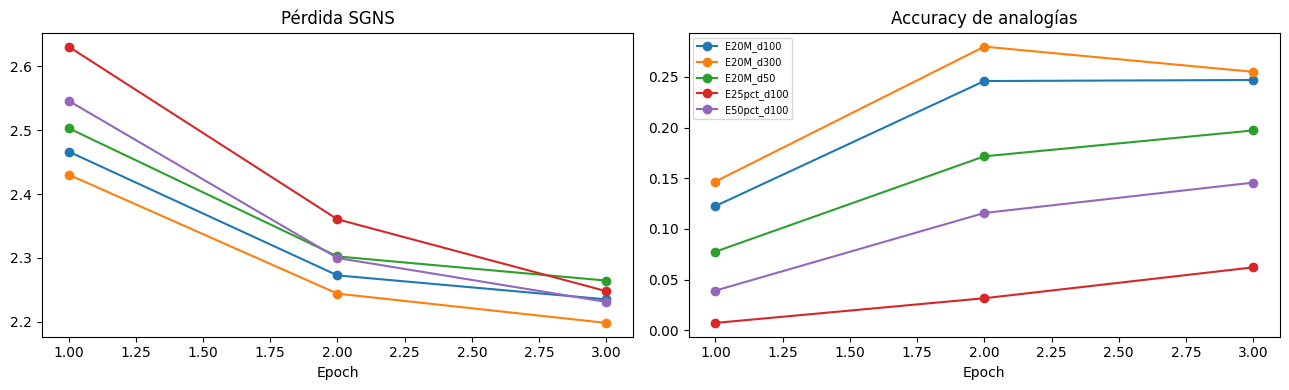

Una pérdida menor optimiza la tarea de negativos, pero no garantiza mejor geometría semántica; se contrasta con las curvas de analogías.


In [9]:
histories=[]
if RUN_EXPERIMENTS:
    for cfg in experiments:
        model,h=train_sgns(cfg); histories.extend(h); del model; gc.collect()
        if DEVICE.type=='cuda': torch.cuda.empty_cache()
hist=pd.DataFrame(histories)
if not hist.empty:
    last=hist.sort_values('epoch').groupby('experiment_id').tail(1).copy()
    last['selection_score']=last.analogy_total.fillna(0)+last.wordsim_spearman.fillna(0)
    best_id=last.sort_values('selection_score').iloc[-1].experiment_id
else: best_id='E20M_d100'
best_cfg=next(x for x in experiments if x['id']==best_id); print('Mejor configuración (sólo WordSim + analogías):',best_cfg)
if not hist.empty:
    fig,ax=plt.subplots(1,2,figsize=(13,4))
    for key,g in hist.groupby('experiment_id'): ax[0].plot(g.epoch,g.loss,marker='o',label=key); ax[1].plot(g.epoch,g.analogy_total,marker='o',label=key)
    ax[0].set(title='Pérdida SGNS',xlabel='Epoch'); ax[1].set(title='Accuracy de analogías',xlabel='Epoch'); ax[1].legend(fontsize=7); plt.tight_layout(); plt.savefig(ROOT/'figures/training_curves.png'); plt.show()
print('Una pérdida menor optimiza la tarea de negativos, pero no garantiza mejor geometría semántica; se contrasta con las curvas de analogías.')

## 3. Word2Vec equivalente y modelos finales

Gensim recibe el mismo flujo de IDs convertido a palabras, el mismo vocabulario fijo, ventana, dimensión, negativos, submuestreo, semilla y épocas que la configuración seleccionada. `workers=1` favorece reproducibilidad.

In [10]:
class TokenChunks:
    def __init__(self,x,n,chunk=1000): self.x=x; self.n=n; self.chunk=chunk
    def __iter__(self):
        for j in range(0,self.n,self.chunk): yield [itos[i] for i in self.x[j:min(j+self.chunk,self.n)]]
stream=TokenChunks(ids,best_cfg['tokens'])
w2v_path=ROOT/'embeddings/word2vec_gensim.kv'; w2v_hist=[]
if w2v_path.exists(): w2v=KeyedVectors.load(str(w2v_path))
else:
    w=Word2Vec(vector_size=best_cfg['dim'],window=best_cfg['window'],sg=1,negative=best_cfg['negative'],hs=0,
               sample=best_cfg['subsample'],min_count=1,workers=1,seed=SEED,compute_loss=True)
    w.build_vocab_from_freq({word:int(counts[i]) for i,word in enumerate(itos) if i})
    prev=0
    for ep in range(best_cfg['epochs']):
        t0=time.time(); w.train(stream,total_examples=math.ceil(best_cfg['tokens']/1000),epochs=1,compute_loss=True); loss=w.get_latest_training_loss(); vec=w.wv.vectors
        _,a=analogy_benchmark(w.wv.index_to_key,vec); ws=wordsim_score(w.wv.index_to_key,vec)
        w2v_hist.append({'epoch':ep+1,'loss':loss-prev,'seconds':time.time()-t0,'analogy_total':a['accuracy'],
                         'analogy_semantic':a['semantic'],'analogy_syntactic':a['syntactic'],'wordsim_spearman':ws['spearman'],
                         'neighbors':json.dumps(nearest(w.wv.index_to_key,vec,['king','france','computer','good','january','run']))}); prev=loss
    w.wv.save(str(w2v_path)); pd.DataFrame(w2v_hist).to_csv(ROOT/'results/gensim_history.csv',index=False); w2v=w.wv
ck=torch.load(ROOT/'checkpoints'/f"{best_id}.pt",map_location='cpu',weights_only=False)
sgns_vectors=ck['model']['input.weight'].numpy(); sgns=KeyedVectors(vector_size=sgns_vectors.shape[1]); sgns.add_vectors(itos,sgns_vectors)
sgns.save(str(ROOT/'embeddings/sgns_best.kv')); sgns.save_word2vec_format(str(ROOT/'embeddings/sgns_best.txt'))
print(sgns,w2v,glove)

KeyedVectors<vector_size=300, 30000 keys> KeyedVectors<vector_size=300, 29999 keys> KeyedVectors<vector_size=100, 400000 keys>


## 4. Aritmética vectorial, benchmark común y t-SNE

`analogia(a,b,c,k)` implementa $b-a+c$ con 3CosAdd, normaliza, excluye las palabras de consulta y devuelve top-k. Además se calcula el rango de la respuesta correcta y se repite sin exclusión. El benchmark usa exactamente la intersección de las 30,000 palabras frecuentes presentes en los tres modelos.

In [11]:
def analogia(kv,a,b,c,k=5,exclude=True):
    if not all(w in kv for w in [a,b,c]): return [],None,None
    words=kv.index_to_key; mat=normalized(kv.vectors.astype(np.float32)); ix=kv.key_to_index
    q=kv[b]-kv[a]+kv[c]; q=q/(np.linalg.norm(q)+1e-12); score=mat@q
    if exclude:
        for w in [a,b,c]: score[ix[w]]=-np.inf
    order=np.argsort(score)[::-1]; return [(words[i],float(score[i])) for i in order[:k]],order,score
own=[('man','woman','king','queen','género'),('boy','girl','king','queen','género'),
('france','paris','italy','rome','capital'),('england','london','germany','berlin','capital'),
('italy','italian','spain','spanish','gentilicio'),('france','french','germany','german','gentilicio'),
('good','better','bad','worse','comparativo'),('slow','slower','fast','faster','comparativo'),
('good','best','bad','worst','superlativo'),('small','smallest','large','largest','superlativo'),
('walk','walking','run','running','verbo'),('swim','swimming','run','running','verbo'),
('cat','cats','dog','dogs','plural'),('book','books','car','cars','plural'),('car','cars','apple','apples','plural')]
rows=[]
for name,kv in {'SGNS':sgns,'gensim':w2v,'GloVe':glove}.items():
    for a,b,c,target,kind in own:
        top,order,score=analogia(kv,a,b,c,5,True); raw,_,_=analogia(kv,a,b,c,5,False)
        rank=int(np.where(order==kv.key_to_index[target])[0][0]+1) if order is not None and target in kv else None
        rows.append({'modelo':name,'tipo':kind,'a':a,'b':b,'c':c,'respuesta':target,'top5':top,'rango':rank,
                     'sim_respuesta':float(score[kv.key_to_index[target]]) if score is not None and target in kv else np.nan,'top1_sin_excluir':raw[0] if raw else None})
individual=pd.DataFrame(rows); individual.to_csv(ROOT/'tables/analogies_individual.csv',index=False); display(individual)
print('Comprobación con gensim:',w2v.most_similar(positive=['woman','king'],negative=['man'],topn=5))

,modelo,tipo,a,b,c,respuesta,top5,rango,sim_respuesta,top1_sin_excluir
0,SGNS,género,man,woman,king,queen,"[(plantagenet, 0.39923998713493347), (beatrice...",10,0.376687,"(king, 0.665785551071167)"
1,SGNS,género,boy,girl,king,queen,"[(skule, 0.3757238984107971), (haakon, 0.36584...",9,0.349500,"(king, 0.5807218551635742)"
2,SGNS,capital,france,paris,italy,rome,"[(milan, 0.42094820737838745), (venice, 0.3922...",4,0.373884,"(paris, 0.6858876943588257)"
3,SGNS,capital,england,london,germany,berlin,"[(riefenstahl, 0.4040578603744507), (berlin, 0...",2,0.394119,"(germany, 0.6605362296104431)"
4,SGNS,gentilicio,italy,italian,spain,spanish,"[(spanish, 0.4283166229724884), (german, 0.350...",1,0.428317,"(spain, 0.6518274545669556)"
5,SGNS,gentilicio,france,french,germany,german,"[(german, 0.42633843421936035), (nigsberg, 0.3...",1,0.426338,"(germany, 0.5983622074127197)"
6,SGNS,comparativo,good,better,bad,worse,"[(worse, 0.30125486850738525), (aggressive, 0....",1,0.301255,"(bad, 0.6694148778915405)"
7,SGNS,comparativo,slow,slower,fast,faster,"[(faster, 0.3969365060329437), (fastest, 0.376...",1,0.396937,"(slower, 0.7988114953041077)"
8,SGNS,superlativo,good,best,bad,worst,"[(ranked, 0.4097520112991333), (favorite, 0.39...",293,0.253380,"(best, 0.6879213452339172)"
9,SGNS,superlativo,small,smallest,large,largest,"[(mongoliensis, 0.3518955111503601), (size, 0....",44,0.283904,"(smallest, 0.8077275156974792)"


Comprobación con gensim: [('consort', 0.7853524684906006), ('heir', 0.7629286050796509), ('marriage', 0.7614604234695435), ('duchess', 0.7609784007072449), ('queen', 0.7514143586158752)]


In [12]:
shared=[w for w in itos[1:] if w in sgns and w in w2v and w in glove][:30000]
bench=[]; category_tables=[]
for name,kv in {'SGNS':sgns,'gensim':w2v,'GloVe':glove}.items():
    vec=np.vstack([kv[w] for w in shared])
    for method in ['add','mul']:
        cats,s=analogy_benchmark(shared,vec,method); s.update(modelo=name,metodo=method); bench.append(s)
        cats['modelo']=name; cats['metodo']=method; category_tables.append(cats)
bench=pd.DataFrame(bench); cats=pd.concat(category_tables,ignore_index=True); bench.to_csv(ROOT/'tables/benchmark_summary.csv',index=False); cats.to_csv(ROOT/'tables/benchmark_categories.csv',index=False)
display(bench,cats)
# Paralelismo: coseno promedio entre vectores diferencia de relaciones del mismo tipo.
par=[]
for name,kv in {'SGNS':sgns,'gensim':w2v,'GloVe':glove}.items():
    for kind,g in pd.DataFrame(own,columns=['a','b','c','d','tipo']).groupby('tipo'):
        dif=[kv[b]-kv[a] for a,b in zip(g.a,g.b) if a in kv and b in kv]
        if len(dif)>1:
            z=normalized(np.vstack(dif)); par.append({'modelo':name,'tipo':kind,'coseno_promedio':float((z@z.T)[np.triu_indices(len(z),1)].mean())})
parallel=pd.DataFrame(par); parallel.to_csv(ROOT/'tables/relation_parallelism.csv',index=False); display(parallel)

,coverage,total,accuracy,semantic,syntactic,modelo,metodo
0,11797,19544,0.257354,0.270045,0.251798,SGNS,add
1,11797,19544,0.230482,0.251949,0.221085,SGNS,mul
2,11797,19544,0.129185,0.108296,0.138330,gensim,add
3,11797,19544,0.111215,0.099109,0.116514,gensim,mul
4,11797,19544,0.661609,0.600223,0.688483,GloVe,add
5,11797,19544,0.643299,0.573775,0.673736,GloVe,mul


,categoria,sum,count,mean,modelo,metodo
0,capital-common-countries,148,380,0.389474,SGNS,add
1,capital-world,454,1130,0.401770,SGNS,add
2,city-in-state,319,1632,0.195466,SGNS,add
3,currency,0,108,0.000000,SGNS,add
4,family,49,342,0.143275,SGNS,add
...,...,...,...,...,...,...
79,gram5-present-participle,628,870,0.721839,GloVe,mul
80,gram6-nationality-adjective,1245,1299,0.958430,GloVe,mul
81,gram7-past-tense,749,1332,0.562312,GloVe,mul
82,gram8-plural,749,992,0.755040,GloVe,mul


,modelo,tipo,coseno_promedio
0,SGNS,capital,0.303270
1,SGNS,comparativo,0.070325
2,SGNS,gentilicio,0.278990
3,SGNS,género,0.158719
4,SGNS,plural,0.025059
5,SGNS,superlativo,0.019038
6,SGNS,verbo,0.111391
7,gensim,capital,0.460478
8,gensim,comparativo,0.160339
9,gensim,gentilicio,0.583637


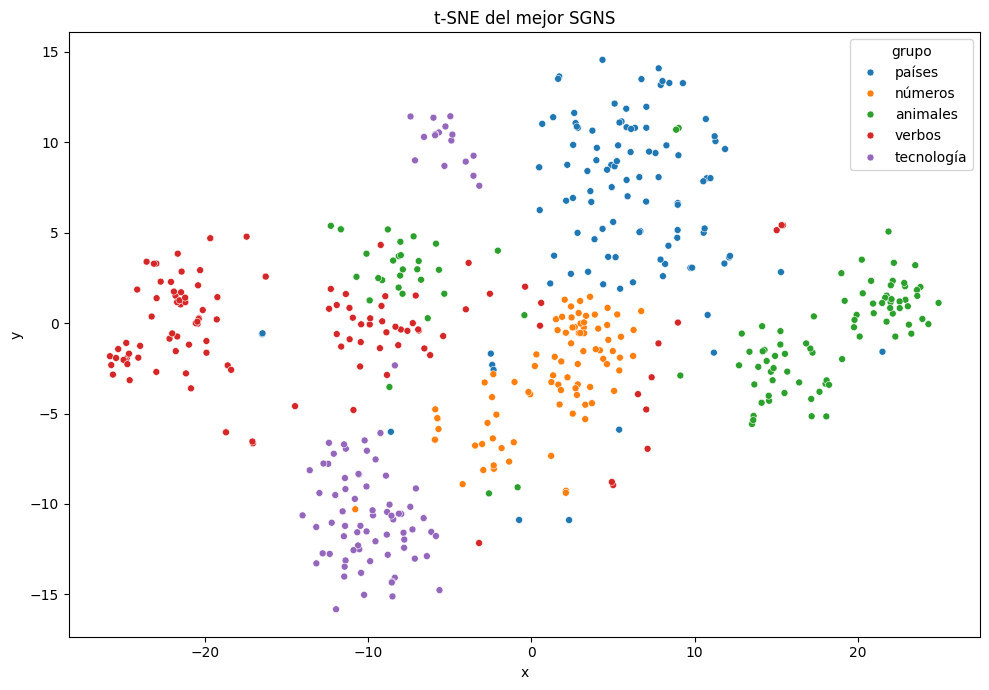

In [13]:
seeds={'países':['country','france','germany','spain'],'números':['one','two','three','million'],
       'animales':['dog','cat','horse','bird'],'verbos':['run','walk','write','play'],'tecnología':['computer','software','internet','data']}
chosen=[]
for label,ss in seeds.items():
    candidates=[]
    for s in ss:
        if s in sgns: candidates += [w for w,_ in sgns.most_similar(s,topn=30)]
    for w in candidates:
        if w not in [x[0] for x in chosen]: chosen.append((w,label))
    chosen=chosen[:len(chosen)]
chosen=chosen[:500]; X=np.vstack([sgns[w] for w,_ in chosen]); perplexity=min(30,max(5,len(chosen)//10))
xy=TSNE(n_components=2,perplexity=perplexity,init='pca',learning_rate='auto',random_state=SEED).fit_transform(X)
ts=pd.DataFrame({'x':xy[:,0],'y':xy[:,1],'palabra':[w for w,_ in chosen],'grupo':[g for _,g in chosen]})
plt.figure(figsize=(10,7)); sns.scatterplot(data=ts,x='x',y='y',hue='grupo',s=25); plt.title('t-SNE del mejor SGNS'); plt.tight_layout(); plt.savefig(ROOT/'figures/tsne.png'); plt.show()

## 5. Clasificación end-to-end de AG News

Se separa 10% estratificado del train oficial. El test no interviene en selección: se evalúa una sola vez la variante ganadora de cada inicialización. Todos los modelos neuronales comparten vocabulario, partición, arquitectura y entrenamiento; sólo cambian inicialización y congelamiento.

In [14]:
texts=np.array(news['train']['text']); labels=np.array(news['train']['label']); test_texts=np.array(news['test']['text']); test_y=np.array(news['test']['label'])
tr_x,va_x,tr_y,va_y=train_test_split(texts,labels,test_size=.10,stratify=labels,random_state=SEED)
news_count=Counter(t for x in tr_x for t in tokenize(x)); cls_words=[w for w,c in news_count.most_common(MAX_VOCAB-2)]
cls_itos=['<pad>','<unk>']+cls_words; cls_stoi={w:i for i,w in enumerate(cls_itos)}
def oov_pct(kv,docs):
    total=miss=0
    for x in docs:
        ts=tokenize(x); total+=len(ts); miss+=sum(w not in kv for w in ts)
    return 100*miss/max(1,total)
oov=pd.DataFrame([{'modelo':n,'oov_pct':oov_pct(kv,texts)} for n,kv in {'SGNS':sgns,'gensim':w2v,'GloVe':glove}.items()]); display(oov); oov.to_csv(ROOT/'tables/agnews_oov.csv',index=False)
tfidf=TfidfVectorizer(preprocessor=normalize_text,tokenizer=tokenize,token_pattern=None,max_features=100000,ngram_range=(1,2),min_df=2)
t0=time.time(); A=tfidf.fit_transform(tr_x); B=tfidf.transform(va_x); lr=LogisticRegression(max_iter=1000,n_jobs=-1).fit(A,tr_y); pred=lr.predict(B)
def metrics(y,p):
    pr,rc,f1,_=precision_recall_fscore_support(y,p,average='macro',zero_division=0); return {'accuracy':accuracy_score(y,p),'precision_macro':pr,'recall_macro':rc,'f1_macro':f1}
tfidf_result={'modelo':'TF-IDF','variante':'baseline',**metrics(va_y,pred),'seconds':time.time()-t0,'total_params':len(lr.coef_.ravel())+len(lr.intercept_),'trainable_params':len(lr.coef_.ravel())+len(lr.intercept_)}
display(pd.DataFrame([tfidf_result]))

,modelo,oov_pct
0,SGNS,7.916624
1,gensim,7.916624
2,GloVe,1.274046


,modelo,variante,accuracy,precision_macro,recall_macro,f1_macro,seconds,total_params,trainable_params
0,TF-IDF,baseline,0.923833,0.923587,0.923833,0.923626,31.76395,400004,400004


In [15]:
class NewsDS(Dataset):
    def __init__(self,x,y): self.x=x; self.y=y
    def __len__(self): return len(self.y)
    def __getitem__(self,i): return [cls_stoi.get(w,1) for w in tokenize(self.x[i])] or [1],int(self.y[i])
def collate(batch):
    seq,y=zip(*batch); offsets=np.cumsum([0]+[len(x) for x in seq[:-1]])
    return torch.tensor(sum(seq,[]),dtype=torch.long),torch.tensor(offsets),torch.tensor(y)
def loader(x,y,shuffle=False): return DataLoader(NewsDS(x,y),batch_size=512,shuffle=shuffle,collate_fn=collate,num_workers=2,pin_memory=True)
class Classifier(nn.Module):
    def __init__(self,matrix,freeze):
        super().__init__(); self.emb=nn.EmbeddingBag.from_pretrained(torch.tensor(matrix),freeze=freeze,mode='mean',padding_idx=0)
        self.net=nn.Sequential(nn.Linear(matrix.shape[1],128),nn.ReLU(),nn.Dropout(.25),nn.Linear(128,4))
    def forward(self,x,o): return self.net(self.emb(x,o))
def matrix_for(kv,dim):
    r=np.zeros((len(cls_itos),dim),np.float32); gen=np.random.default_rng(SEED); r[1:]=gen.normal(0,.02,r[1:].shape)
    if kv is not None:
        for i,w in enumerate(cls_itos[2:],2):
            if w in kv: r[i]=kv[w]
    return r
@torch.inference_mode()
def predict_model(model,dl):
    model.eval(); ys=[]; ps=[]; loss=0
    for x,o,y in dl:
        x,o,y=x.to(DEVICE),o.to(DEVICE),y.to(DEVICE); z=model(x,o); loss+=F.cross_entropy(z,y,reduction='sum').item(); ys.extend(y.cpu()); ps.extend(z.argmax(1).cpu())
    return np.array(ys),np.array(ps),loss/len(ys)
def train_classifier(name,matrix,freeze,train_data=(tr_x,tr_y),epochs=8):
    model=Classifier(matrix,freeze).to(DEVICE); opt=torch.optim.AdamW(filter(lambda p:p.requires_grad,model.parameters()),lr=1e-3); best=(-1,None); hist=[]; t0=time.time()
    dl=loader(*train_data,True); vl=loader(va_x,va_y)
    for ep in range(epochs if not FAST_MODE else 1):
        model.train(); total=0
        for x,o,y in dl:
            x,o,y=x.to(DEVICE),o.to(DEVICE),y.to(DEVICE); opt.zero_grad(); loss=F.cross_entropy(model(x,o),y); loss.backward(); opt.step(); total+=loss.item()*len(y)
        yy,pp,vloss=predict_model(model,vl); m=metrics(yy,pp); hist.append({'epoch':ep+1,'train_loss':total/len(dl.dataset),'val_loss':vloss,**m})
        if m['f1_macro']>best[0]: best=(m['f1_macro'],{k:v.detach().cpu().clone() for k,v in model.state_dict().items()})
    model.load_state_dict(best[1]); total=sum(p.numel() for p in model.parameters()); trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
    result={'modelo':name,'variante':'congelado' if freeze else 'fine_tuning',**hist[np.argmax([x['f1_macro'] for x in hist])],
            'seconds':time.time()-t0,'total_params':total,'trainable_params':trainable}
    return model,result,pd.DataFrame(hist)

,modelo,variante,accuracy,precision_macro,recall_macro,f1_macro,seconds,total_params,trainable_params,epoch,train_loss,val_loss
0,TF-IDF,baseline,0.923833,0.923587,0.923833,0.923626,31.763950,400004,400004,NaN,NaN,NaN
1,Aleatorio,fine_tuning,0.922833,0.922733,0.922833,0.922693,99.610392,3013444,3013444,3.0,0.194598,0.233046
2,SGNS,congelado,0.884833,0.884499,0.884833,0.884493,98.920764,9039044,39044,8.0,0.340316,0.334429
3,SGNS,fine_tuning,0.922167,0.922385,0.922167,0.922119,100.207211,9039044,9039044,3.0,0.173147,0.233180
4,GloVe,congelado,0.897417,0.897634,0.897417,0.897160,99.628583,3013444,13444,6.0,0.322377,0.311760
5,GloVe,fine_tuning,0.924500,0.924496,0.924500,0.924374,99.720889,3013444,3013444,6.0,0.163275,0.228462


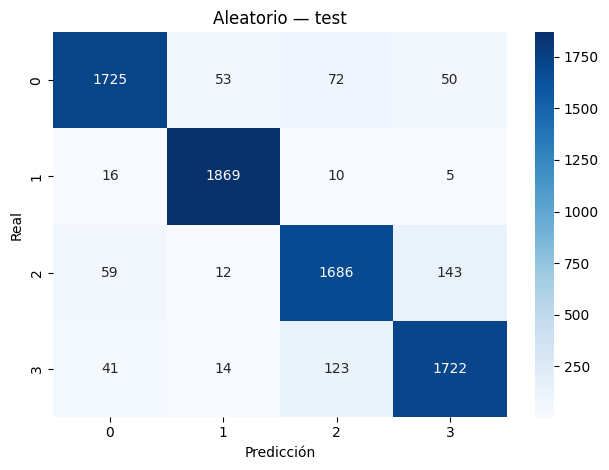

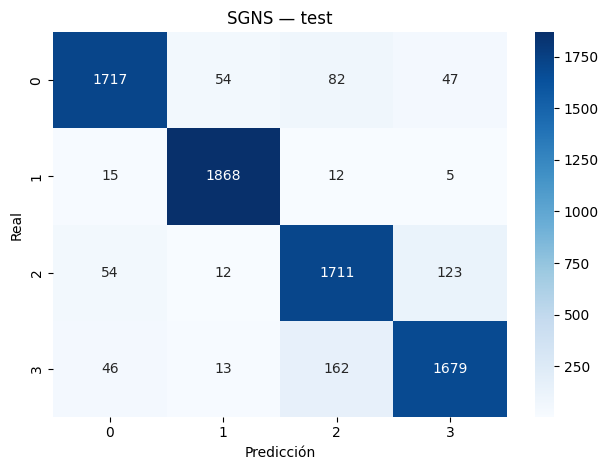

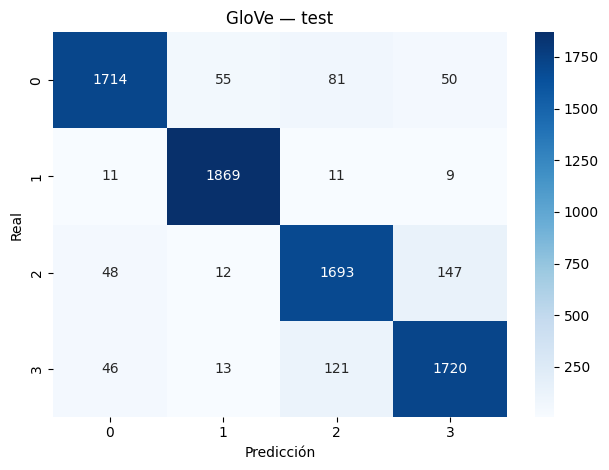

,modelo,variante,accuracy,precision_macro,recall_macro,f1_macro
0,TF-IDF,baseline,0.921447,0.921363,0.921447,0.921325
1,Aleatorio,fine_tuning,0.921316,0.921226,0.921316,0.921168
2,SGNS,fine_tuning,0.917763,0.918028,0.917763,0.917683
3,GloVe,fine_tuning,0.920526,0.920630,0.920526,0.920418


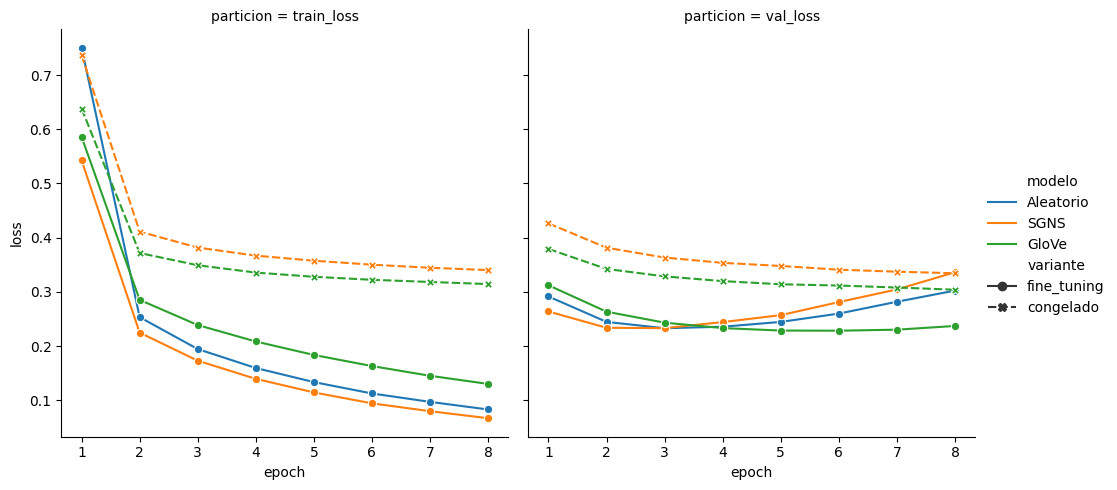

In [16]:
runs=[]; saved={}; curves=[]
initializations={'Aleatorio':matrix_for(None,100),'SGNS':matrix_for(sgns,sgns.vector_size),'GloVe':matrix_for(glove,100)}
if RUN_CLASSIFIERS:
    for name,mat in initializations.items():
        variants=[False] if name=='Aleatorio' else [True,False]
        for freeze in variants:
            model,res,h=train_classifier(name,mat,freeze); runs.append(res); saved[(name,res['variante'])]=model; h['modelo']=name; h['variante']=res['variante']; curves.append(h)
results=pd.DataFrame([tfidf_result]+runs); results.to_csv(ROOT/'tables/classification_validation.csv',index=False); display(results)
# Una evaluación de test por inicialización, elegida exclusivamente por F1 de validación.
test_rows=[]
tf_test=lr.predict(tfidf.transform(test_texts)); test_rows.append({'modelo':'TF-IDF','variante':'baseline',**metrics(test_y,tf_test)})
for name in initializations:
    winner=results[results.modelo==name].sort_values('f1_macro').iloc[-1]; model=saved[(name,winner.variante)]
    yy,pp,_=predict_model(model,loader(test_texts,test_y)); test_rows.append({'modelo':name,'variante':winner.variante,**metrics(yy,pp)})
    cm=confusion_matrix(yy,pp); sns.heatmap(cm,annot=True,fmt='d',cmap='Blues'); plt.title(f'{name} — test'); plt.xlabel('Predicción'); plt.ylabel('Real'); plt.tight_layout(); plt.savefig(ROOT/'figures'/f'confusion_{name}.png'); plt.show()
test_results=pd.DataFrame(test_rows); test_results.to_csv(ROOT/'tables/classification_test.csv',index=False); display(test_results)
if curves:
    cv=pd.concat(curves); long=cv.melt(id_vars=['epoch','modelo','variante'],value_vars=['train_loss','val_loss'],var_name='particion',value_name='loss')
    sns.relplot(data=long,x='epoch',y='loss',hue='modelo',style='variante',col='particion',kind='line',markers=True); plt.savefig(ROOT/'figures/classification_loss.png'); plt.show()

,spearman,coverage,total,modelo
0,NaN,0,0,SGNS
1,NaN,0,0,gensim
2,NaN,0,0,GloVe


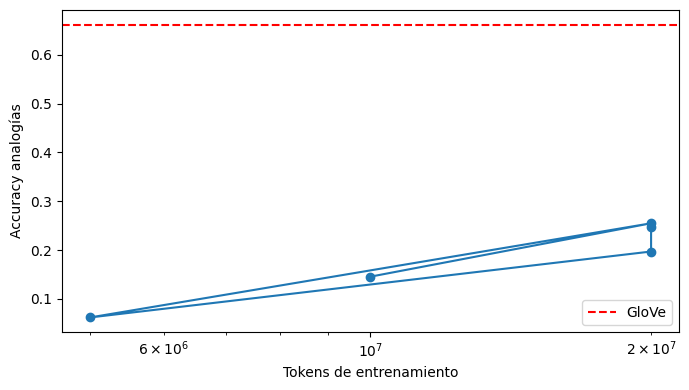

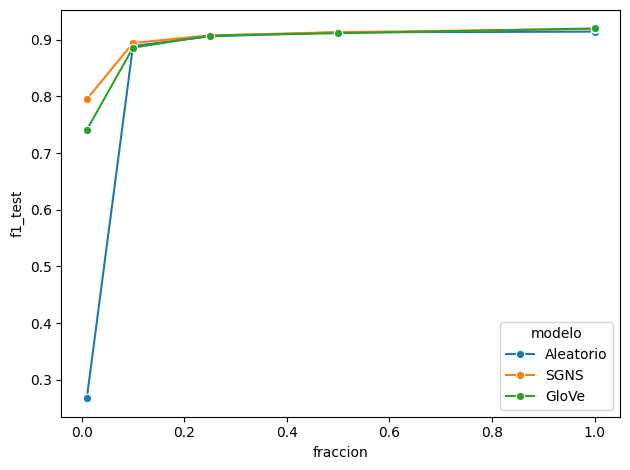

In [17]:
# Evaluación final reservada: SimLex-999.
simlex_rows=[]
for name,kv in {'SGNS':sgns,'gensim':w2v,'GloVe':glove}.items():
    s=wordsim_score(kv.index_to_key,kv.vectors,SIMLEX); s['modelo']=name; simlex_rows.append(s)
simlex=pd.DataFrame(simlex_rows); simlex.to_csv(ROOT/'tables/simlex_final.csv',index=False); display(simlex)
# Curva analogías vs tokens, con GloVe como referencia.
if not hist.empty:
    final=hist.sort_values('epoch').groupby('experiment_id').tail(1).merge(pd.DataFrame(experiments)[['id','tokens']],left_on='experiment_id',right_on='id')
    glove_acc=float(bench.query("modelo=='GloVe' and metodo=='add'").accuracy.iloc[0]); plt.figure(figsize=(7,4)); plt.plot(final.tokens,final.analogy_total,'o-'); plt.axhline(glove_acc,color='red',ls='--',label='GloVe'); plt.xscale('log'); plt.xlabel('Tokens de entrenamiento'); plt.ylabel('Accuracy analogías'); plt.legend(); plt.tight_layout(); plt.savefig(ROOT/'figures/analogies_vs_tokens.png'); plt.show()
# RUN_FRACTION_CURVES es opcional por costo; usa configuración ya elegida, no selecciona con test.
fraction_rows=[]
if RUN_FRACTION_CURVES:
    for frac in [.01,.10,.25,.50,1.0]:
        sx,_,sy,_=train_test_split(tr_x,tr_y,train_size=frac,random_state=SEED,stratify=tr_y) if frac<1 else (tr_x,None,tr_y,None)
        for name,mat in initializations.items():
            best_variant=results[results.modelo==name].sort_values('f1_macro').iloc[-1].variante; model,_,_=train_classifier(name,mat,best_variant=='congelado',(sx,sy))
            yy,pp,_=predict_model(model,loader(test_texts,test_y)); fraction_rows.append({'fraccion':frac,'modelo':name,'f1_test':metrics(yy,pp)['f1_macro']})
    fr=pd.DataFrame(fraction_rows); fr.to_csv(ROOT/'tables/fraction_curve.csv',index=False); sns.lineplot(data=fr,x='fraccion',y='f1_test',hue='modelo',marker='o'); plt.tight_layout(); plt.savefig(ROOT/'figures/f1_vs_fraction.png'); plt.show()

## 6. Tabla comparativa y guía para la discusión

La siguiente celda consolida resultados medidos. Para el PDF, interprete los valores (no sólo los copie): categorías semánticas frente a sintácticas; top-1 sin exclusión como evidencia de que $\approx$ no es igualdad; paralelismo de vectores diferencia; brecha con GloVe frente a tamaño del corpus; similitud SGNS–gensim; efecto de dimensión/tamaño; y, en AG News, preentrenamiento, congelamiento y el caso de 1%. El hardware de GloVe debe citarse desde la publicación original si sus autores lo reportan; no se inventa aquí.

In [18]:
comparison=[]
for name,kv,tok,seconds in [('SGNS',sgns,best_cfg['tokens'],sum(x['seconds'] for x in ck['history'])),
                            ('gensim',w2v,best_cfg['tokens'],sum(x['seconds'] for x in w2v_hist) if w2v_hist else np.nan),
                            ('GloVe',glove,6_000_000_000,np.nan)]:
    badd=bench.query('modelo==@name and metodo=="add"').iloc[0]; bmul=bench.query('modelo==@name and metodo=="mul"').iloc[0]
    comparison.append({'modelo':name,'tokens_corpus':tok,'vocabulario':len(kv),'dimension':kv.vector_size,'tiempo_seg':seconds,
      'hardware':torch.cuda.get_device_name(0) if name!='GloVe' and torch.cuda.is_available() else ('CPU' if name!='GloVe' else 'consultar paper'),
      '3CosAdd_total':badd.accuracy,'3CosAdd_sem':badd.semantic,'3CosAdd_sint':badd.syntactic,
      '3CosMul_total':bmul.accuracy,'3CosMul_sem':bmul.semantic,'3CosMul_sint':bmul.syntactic,
      'WordSim353':wordsim_score(kv.index_to_key,kv.vectors)['spearman'],
      'SimLex999':simlex.query('modelo==@name').spearman.iloc[0],
      'paralelismo':parallel.query('modelo==@name').coseno_promedio.mean(),
      'AGNews_OOV_pct':oov.query('modelo==@name').oov_pct.iloc[0],
      'AGNews_F1_test':test_results.query('modelo==@name').f1_macro.iloc[0] if name in ['SGNS','GloVe'] else np.nan})
comparison=pd.DataFrame(comparison); comparison.to_csv(ROOT/'tables/final_comparison.csv',index=False); display(comparison)
# Manifiesto y ZIP descargable desde la pestaña Output de Kaggle.
manifest=[str(p.relative_to(ROOT)) for p in ROOT.rglob('*') if p.is_file()]
(ROOT/'manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf8')
import shutil
archive=shutil.make_archive('/kaggle/working/lab7_resultados' if Path('/kaggle/working').exists() else str(Path.cwd()/'lab7_resultados'),'zip',ROOT)
print('Artefactos:',len(manifest),'ZIP:',archive)

,modelo,tokens_corpus,vocabulario,dimension,tiempo_seg,hardware,3CosAdd_total,3CosAdd_sem,3CosAdd_sint,3CosMul_total,3CosMul_sem,3CosMul_sint,WordSim353,SimLex999,paralelismo,AGNews_OOV_pct,AGNews_F1_test
0,SGNS,20000000,30000,300,175.550253,Tesla T4,0.257354,0.270045,0.251798,0.230482,0.251949,0.221085,0.643233,NaN,0.138113,7.916624,0.917683
1,gensim,20000000,29999,300,239.953145,Tesla T4,0.129185,0.108296,0.138330,0.111215,0.099109,0.116514,0.581013,NaN,0.307108,7.916624,NaN
2,GloVe,6000000000,400000,100,NaN,consultar paper,0.661609,0.600223,0.688483,0.643299,0.573775,0.673736,0.532735,NaN,0.526183,1.274046,0.920418


Artefactos: 40 ZIP: /kaggle/working/lab7_resultados.zip
